blackhole_orbits/
│
├── orbits.py           # Main simulation code for calculating black hole orbits
├── test_orbits.py      # Unit tests using pytest to ensure the correctness of the simulation code
├── outputfolder/       # Directory to store orbital history, simulation outputs, and results
├── README.md           # Documentation on how to use and run the module, including setup instructions
├── analysis.ipynb      # Jupyter notebook for explaining the simulation results and performing comparisons
└── init.py         # Optional file to make this directory a Python package

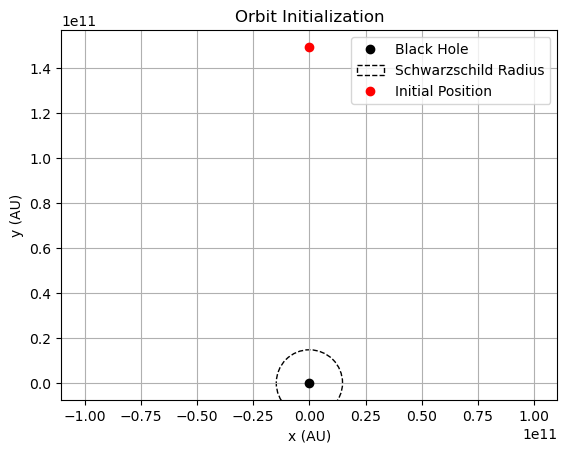

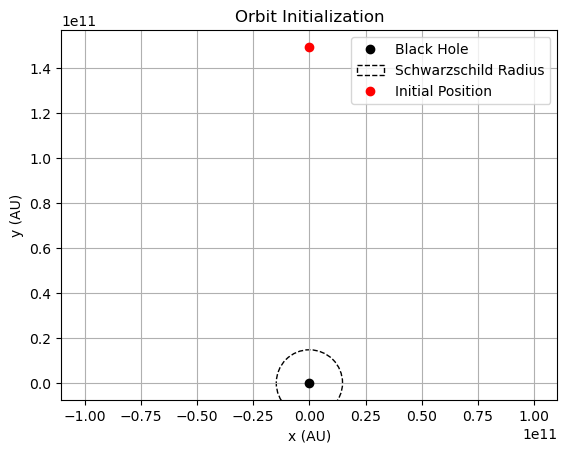

Simulation results saved to output/classical_orbit_history.csv
Simulation results saved to output/relativistic_orbit_history.csv


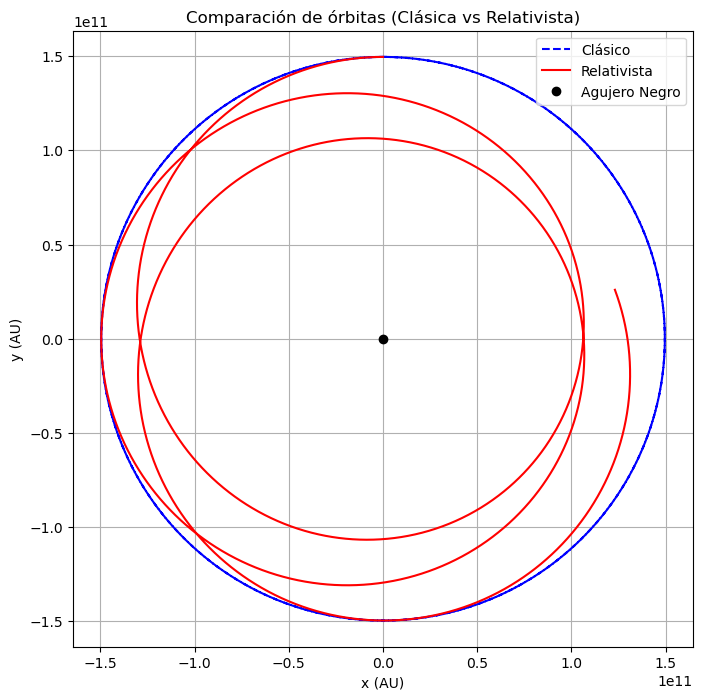

In [9]:
from orbits import Orbits  # asumiendo que guardaste el código en Orbit_Simulation.py
import numpy as np
import matplotlib.pyplot as plt

# Constantes
AU = 1.496e11  # m
M_sun = 1.989e30  # kg
M = 5e6 * M_sun
a = 1 * AU
e = 0
N = 2

# Inicializar órbitas
orbit_classical = Orbits("classical")
orbit_classical.initialize_orbit(M, a, e, N)

orbit_relativistic = Orbits("relativistic")
orbit_relativistic.initialize_orbit(M, a, e, N)

# Calcular periodo orbital (Kepler)
T = 2 * np.pi * np.sqrt(a**3 / (6.67430e-11 * M))
t_span = (0, N * T)
t_eval = np.linspace(0, N * T, 10000)

# Simulación clásica
y_classical = orbit_classical.run_simulation(
    slope_function=orbit_classical.classical_slope,
    integration_method="rk3",
    t_span=t_span,
    t_eval=t_eval,
    output_folder="output"
)

# Simulación relativista
y_relativistic = orbit_relativistic.run_simulation(
    slope_function=orbit_relativistic.relativistic_slope,
    integration_method="rk3",
    t_span=t_span,
    t_eval=t_eval,
    output_folder="output"
)

# Graficar ambas órbitas
plt.figure(figsize=(8, 8))
plt.plot(y_classical[:, 0], y_classical[:, 1], label="Clásico", linestyle='--', color='blue')
plt.plot(y_relativistic[:, 0], y_relativistic[:, 1], label="Relativista", color='red')
plt.plot(0, 0, 'ko', label="Agujero Negro")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Comparación de órbitas (Clásica vs Relativista)")
plt.legend(loc="upper right")
plt.grid(True)
plt.axis("equal")
plt.show()


Diferencia máxima entre órbitas (en AU): 1.848887e+00
Diferencia promedio entre órbitas (en AU): 1.285862e+00


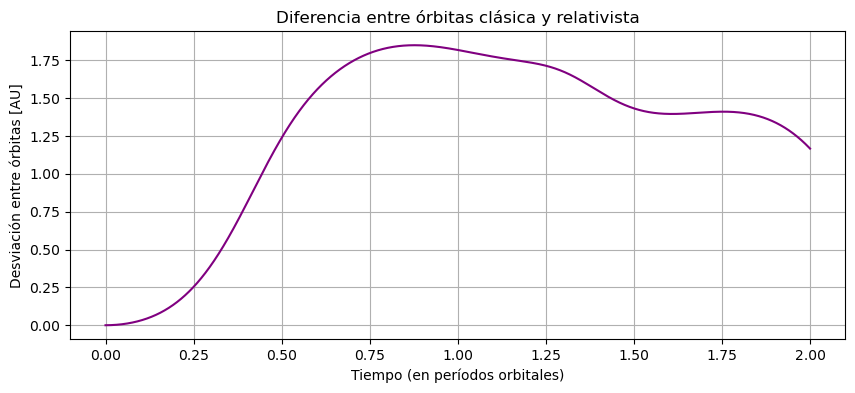

In [6]:
# Convertir posiciones de metros a AU para mejor interpretación
def to_au(arr):
    return arr / AU

# Calcular diferencia punto a punto
delta = np.sqrt((y_relativistic[:, 0] - y_classical[:, 0])**2 + (y_relativistic[:, 1] - y_classical[:, 1])**2)
delta_au = to_au(delta)

# Estadísticas
max_diff = np.max(delta_au)
mean_diff = np.mean(delta_au)

# Mostrar resultados
print(f"Diferencia máxima entre órbitas (en AU): {max_diff:.6e}")
print(f"Diferencia promedio entre órbitas (en AU): {mean_diff:.6e}")

# Gráfico de diferencia en el tiempo
plt.figure(figsize=(10, 4))
plt.plot(t_eval / T, delta_au, color='purple')
plt.xlabel("Tiempo (en períodos orbitales)")
plt.ylabel("Desviación entre órbitas [AU]")
plt.title("Diferencia entre órbitas clásica y relativista")
plt.grid(True)
plt.show()


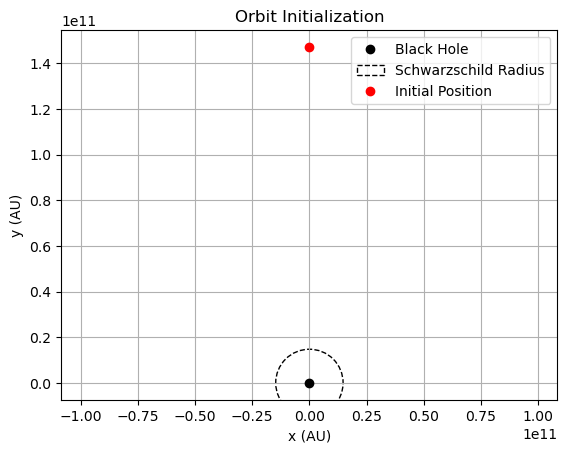

Simulation results saved to output/Earth_orbit_history.csv
Earth - Max x: 0.98 AU, Max y: 0.98 AU


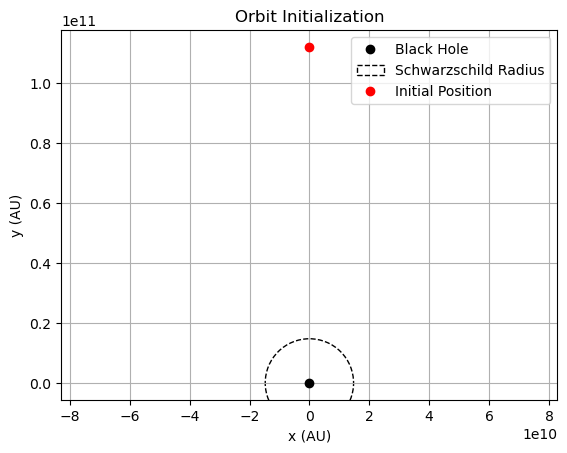

Simulation results saved to output/Pluto_orbit_history.csv
Pluto - Max x: 0.76 AU, Max y: 0.76 AU


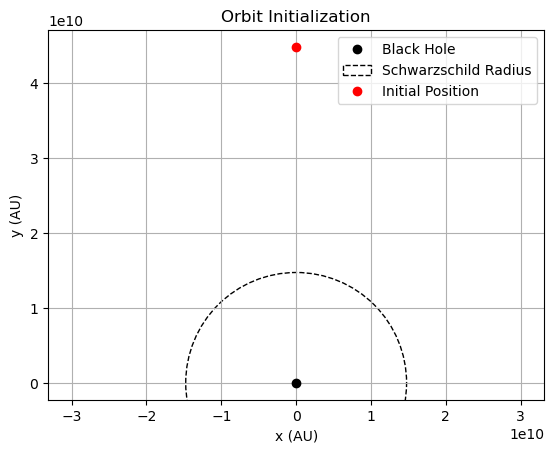

Simulation results saved to output/7092 Cadmus_orbit_history.csv
7092 Cadmus - Max x: 2669.04 AU, Max y: 6012.20 AU


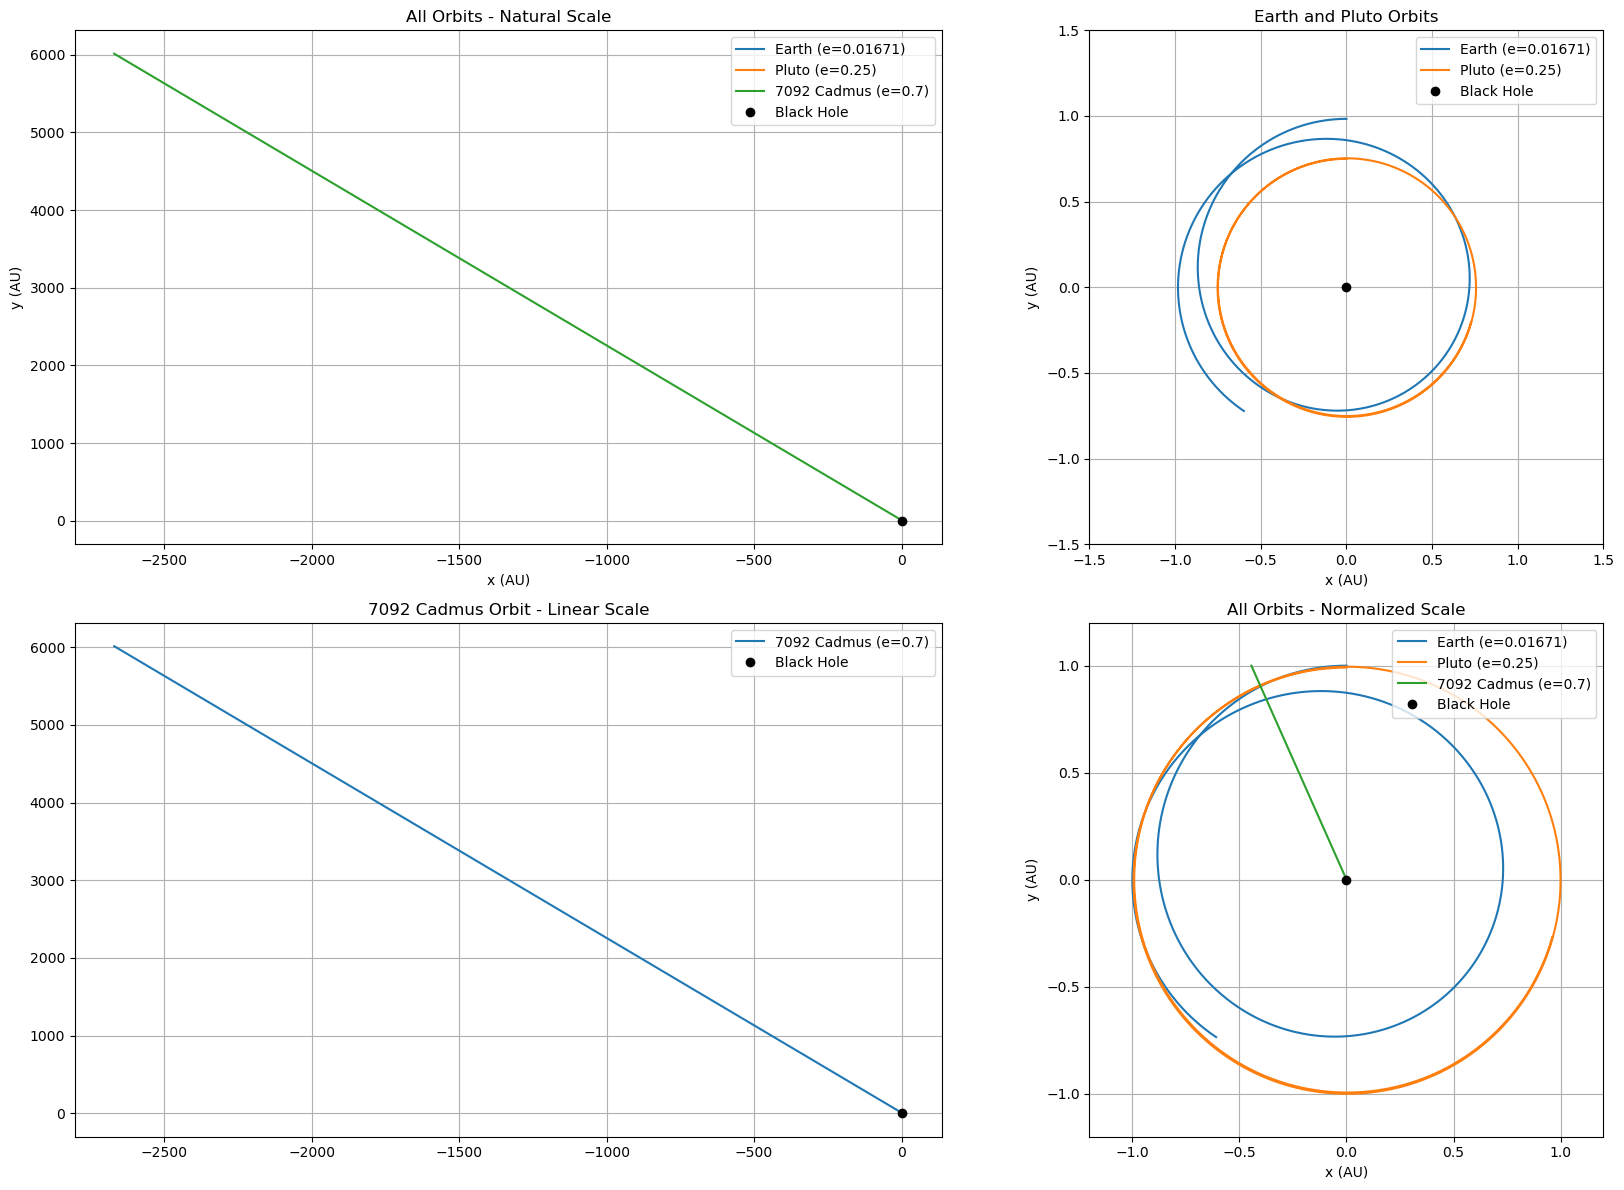

In [31]:
# Constants
AU = 1.496e11  # 1 Astronomical Unit in meters
M_sun = 1.989e30  # Mass of the Sun in kg
M = 5e6 * M_sun  # Mass of the black hole
a = 1 * AU  # Semi-major axis in meters
N = 1000  # Number of steps
method = "trapz"  # Integration method

# Gravitational constant
G = 6.67430e-11  # m^3 kg^-1 s^-2

# Objects with their eccentricities
objects = [
    {"name": "Earth", "eccentricity": 0.01671},
    {"name": "Pluto", "eccentricity": 0.25},
    {"name": "7092 Cadmus", "eccentricity": 0.70},
]

# Orbital period using Kepler's third law
orbital_period = 2 * np.pi * np.sqrt((a**3) / (G * M))
t_span = (0, orbital_period)
t_eval = np.linspace(0, orbital_period, N)

# Simulate orbits
results = []
for obj in objects:
    orbit = Orbits(obj["name"])
    orbit.initialize_orbit(M, a, obj["eccentricity"], N)
    result = orbit.run_simulation(
        slope_function=orbit.relativistic_slope,
        integration_method=method,
        t_span=t_span,
        t_eval=t_eval,
        output_folder="output"
    )
    results.append({"name": obj["name"], "eccentricity": obj["eccentricity"], "result": result})
    x, y = result[:, 0], result[:, 1]
    print(f"{obj['name']} - Max x: {np.max(np.abs(x))/AU:.2f} AU, Max y: {np.max(np.abs(y))/AU:.2f} AU")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# 1. All orbits on the same scale
for res in results:
    x, y = res["result"][:, 0] / AU, res["result"][:, 1] / AU
    axes[0].plot(x, y, label=f"{res['name']} (e={res['eccentricity']})")
axes[0].plot(0, 0, 'ko', label="Black Hole")
axes[0].set_title("All Orbits - Natural Scale")
axes[0].legend()
axes[0].set_xlabel("x (AU)")
axes[0].set_ylabel("y (AU)")
axes[0].grid(True)

# 2. Earth and Pluto on appropriate scale
for res in results:
    if res["name"] in ["Earth", "Pluto"]:
        x, y = res["result"][:, 0] / AU, res["result"][:, 1] / AU
        axes[1].plot(x, y, label=f"{res['name']} (e={res['eccentricity']})")
axes[1].plot(0, 0, 'ko', label="Black Hole")
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_aspect('equal')
axes[1].set_xlabel("x (AU)")
axes[1].set_ylabel("y (AU)")
axes[1].set_title("Earth and Pluto Orbits")
axes[1].legend()
axes[1].grid(True)

# 3. Cadmus with linear scale
for res in results:
    if res["name"] == "7092 Cadmus":
        x, y = res["result"][:, 0] / AU, res["result"][:, 1] / AU
        axes[2].plot(x, y, label=f"{res['name']} (e={res['eccentricity']})")
axes[2].plot(0, 0, 'ko', label="Black Hole")
axes[2].set_title("7092 Cadmus Orbit - Linear Scale")
axes[2].legend()
axes[1].set_xlabel("x (AU)")
axes[1].set_ylabel("y (AU)")
axes[2].grid(True)

# 4. Normalized scale for shape comparison
for res in results:
    x, y = res["result"][:, 0], res["result"][:, 1]
    max_extent = max(np.max(np.abs(x)), np.max(np.abs(y)))
    if max_extent > 0:
        axes[3].plot(x / max_extent, y / max_extent, label=f"{res['name']} (e={res['eccentricity']})")
axes[3].plot(0, 0, 'ko', label="Black Hole")
axes[3].set_xlim(-1.2, 1.2)
axes[3].set_ylim(-1.2, 1.2)
axes[3].set_aspect('equal')
axes[3].set_title("All Orbits - Normalized Scale")
axes[3].set_xlabel("x (AU)")
axes[3].set_ylabel("y (AU)")
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()